# Forecasting de Producción Mensual de Cerveza en EE.UU. (Barriles)

**Materia:** Series Temporales — Maestría en Ciencias de la Inteligencia Artificial
**Universidad:** Universidad Nacional de Asunción (FIUNA)
**Profesores:** Dr. Diego Stalder — Msc. Enrique Paiva

**Integrantes:**
- Daira Pérez (Ingeniera de Alimentos)
- Malena Russo (Ingeniera Química)

**Fecha:** Julio 2026

---

## Descripción del problema

La industria cervecera de EE.UU. reporta mensualmente su producción total ante la
*Alcohol and Tobacco Tax and Trade Bureau (TTB)*. En este proyecto se busca predecir
la **producción mensual de cerveza, medida en barriles**, a nivel nacional. Contar con
una predicción confiable permite anticipar necesidades de insumos (malta, lúpulo,
cereales), planificar logística de distribución y dimensionar la capacidad productiva
del sector.

## Dataset

**Fuente:** [Beer Production — Kaggle (jessemostipak)](https://www.kaggle.com/datasets/jessemostipak/beer-production)
**Origen original:** Alcohol and Tobacco Tax and Trade Bureau (TTB), vía TidyTuesday (2020-03-31)
**Licencia:** CC0 Public Domain
**Archivo utilizado:** `beer_taxed.csv`
**Frecuencia:** Mensual, 2008–2019 (144 observaciones)
**Variable objetivo:** Barriles producidos por mes (`type='Production'`, `tax_status='Totals'`)

## Bloque 1: Carga de librerías y datos

Importamos las librerías necesarias para manejo de datos, visualización y análisis
de series de tiempo (`pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`).
Luego cargamos el dataset `beer_taxed.csv` y verificamos su estructura (columnas,
cantidad de filas) para confirmar que la carga fue exitosa.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

df_raw = pd.read_csv('beer_taxed.csv')
print("Dimensiones:", df_raw.shape)
df_raw.head()

Dimensiones: (1580, 10)


,data_type,tax_status,year,month,type,month_current,month_prior_year,ytd_current,ytd_prior_year,tax_rate
0,Barrels Produced,Totals,2008,1,Production,16211480,15880125,16211480.0,15880125.0,$7/$18 per barrel
1,Barrels Produced,Taxable,2008,1,In bottles and cans,13222104,12824278,13222104.0,12824278.0,$7/$18 per barrel
2,Barrels Produced,Taxable,2008,1,In barrels and kegs,1371239,1357372,1371239.0,1357372.0,$7/$18 per barrel
3,Barrels Produced,Taxable,2008,1,"Tax Determined, Premises Use",7426,8419,7426.0,8419.0,$7/$18 per barrel
4,Barrels Produced,Sub Total Taxable,2008,1,Sub Total Taxable,14600769,14190069,14600769.0,14190069.0,$7/$18 per barrel


## Bloque 2: Filtrado de la serie de producción y construcción del índice temporal

Del dataset completo, filtramos únicamente las filas correspondientes a
`tax_status == 'Totals'` y `type == 'Production'`, que representan la producción
total mensual de cerveza en barriles. Convertimos las columnas `year` y `month`
en una columna de fecha (`date`) para tratar la serie como una serie de tiempo
correctamente indexada.

In [9]:
# Filtrar la producción total mensual
df_prod = df_raw[
    (df_raw['tax_status'] == 'Totals') &
    (df_raw['type'] == 'Production')
].copy()

# Construir columna de fecha
df_prod['date'] = pd.to_datetime(
    df_prod['year'].astype(str) + '-' + df_prod['month'].astype(str) + '-01'
)

# Ordenar y setear índice temporal
df_prod = df_prod.sort_values('date').set_index('date')

# Quedarnos con la serie de interés (barriles producidos ese mes)
serie_produccion = df_prod['month_current']

print("Rango de fechas:", serie_produccion.index.min(), "-", serie_produccion.index.max())
print("Cantidad de observaciones:", len(serie_produccion))
print("Valores nulos:", serie_produccion.isnull().sum())
serie_produccion.head()

Rango de fechas: 2008-01-01 00:00:00 - 2019-12-01 00:00:00
Cantidad de observaciones: 144
Valores nulos: 0


,month_current
date,
2008-01-01,16211480
2008-02-01,15690494
2008-03-01,17367476
2008-04-01,17254160
2008-05-01,18269043


## Bloque 3: Visualización de la serie temporal

Graficamos la serie de producción mensual de cerveza para observar visualmente
su tendencia y estacionalidad a lo largo de los 12 años de historial disponible.

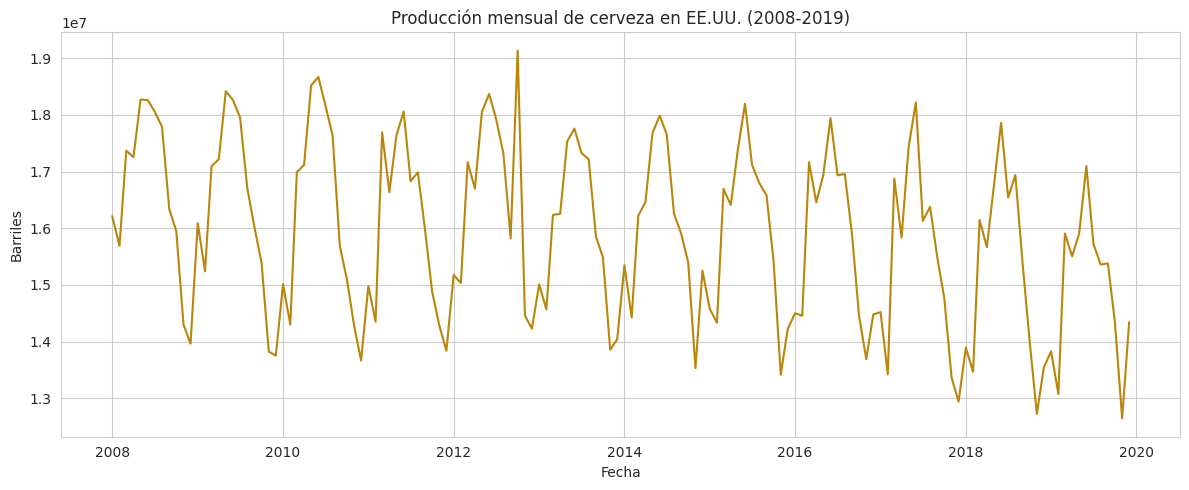

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(serie_produccion.index, serie_produccion.values, color='#B8860B', linewidth=1.5)
plt.title('Producción mensual de cerveza en EE.UU. (2008-2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.tight_layout()
plt.show()

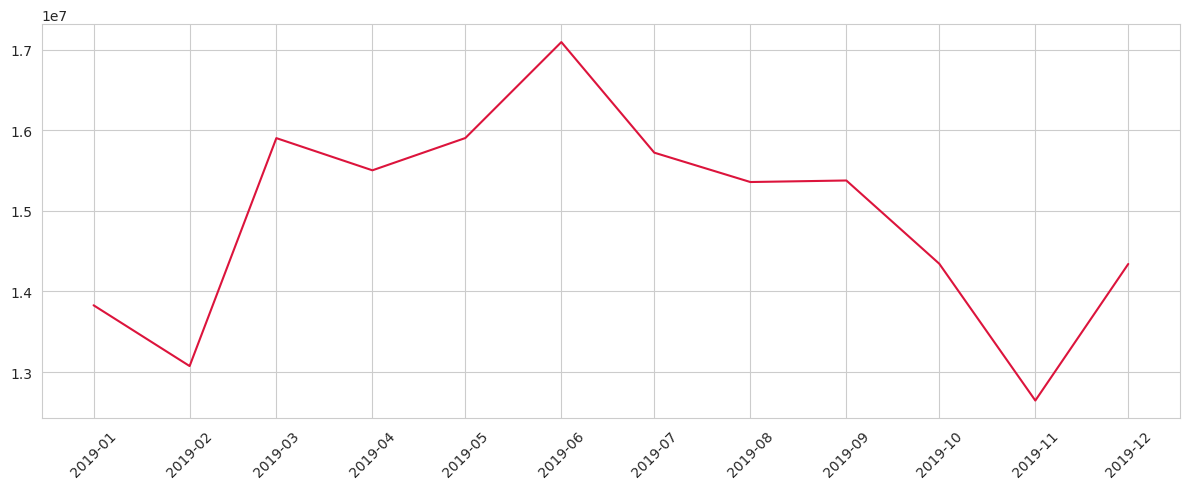

In [15]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test.values, color='#DC143C')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bloque 4: Test de estacionariedad (ADF) y descomposición de la serie

Aplicamos el test de Dickey-Fuller aumentado (ADF) para evaluar si la serie es
estacionaria en su forma original. Adicionalmente, descomponemos la serie en sus
componentes de tendencia, estacionalidad y residuo, para visualizar por separado
cada patrón detectado.

Estadístico ADF: -0.2752
p-valor: 0.9289
Valores críticos:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788

→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación)


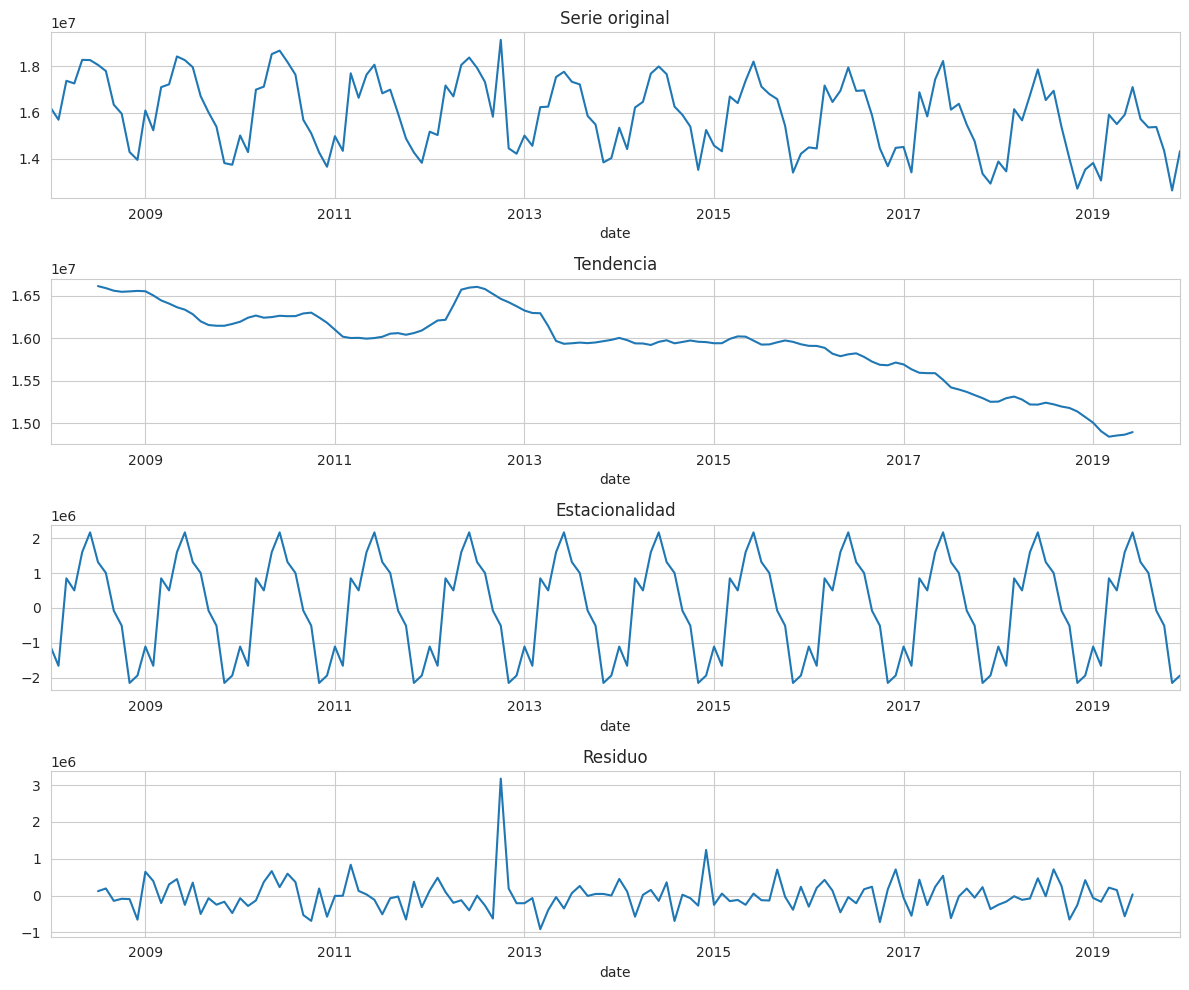

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Test de Dickey-Fuller aumentado
resultado_adf = adfuller(serie_produccion)
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.4f}")
print("Valores críticos:")
for key, value in resultado_adf[4].items():
    print(f"   {key}: {value:.4f}")

if resultado_adf[1] < 0.05:
    print("\n→ Se rechaza H0: la serie ES estacionaria")
else:
    print("\n→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación)")

# Descomposición de la serie (aditiva, período 12 = mensual)
descomposicion = seasonal_decompose(serie_produccion, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
descomposicion.observed.plot(ax=axes[0], title='Serie original')
descomposicion.trend.plot(ax=axes[1], title='Tendencia')
descomposicion.seasonal.plot(ax=axes[2], title='Estacionalidad')
descomposicion.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

## Bloque 5: Diferenciación para lograr estacionariedad

Dado que el test ADF confirmó que la serie no es estacionaria, aplicamos
diferenciación estacional (lag=12, para remover el ciclo anual) y luego
diferenciación regular (lag=1, para remover la tendencia remanente).
Verificamos con un nuevo test ADF si la serie resultante ya es estacionaria.

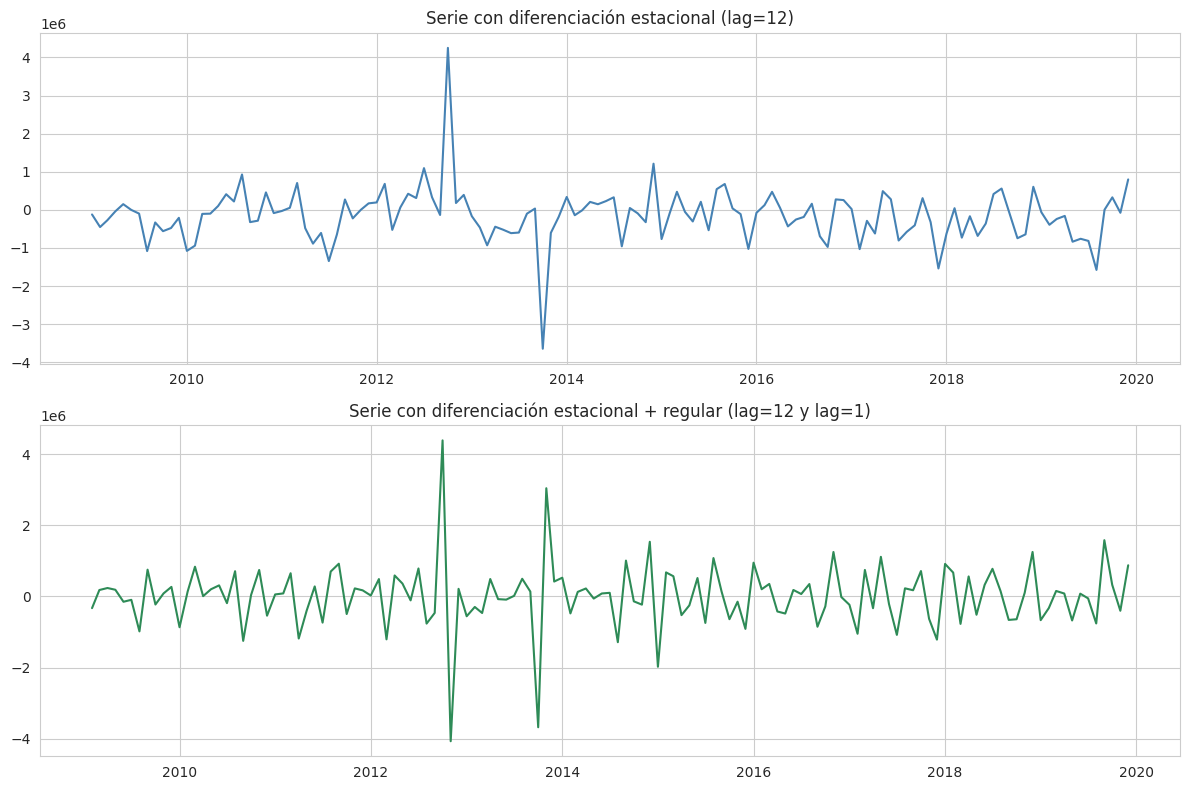

Estadístico ADF: -4.9437
p-valor: 0.0000

→ Se rechaza H0: la serie diferenciada ES estacionaria ✓


In [12]:
# Diferenciación estacional (elimina el ciclo anual, lag=12)
serie_diff_estacional = serie_produccion.diff(12).dropna()

# Diferenciación regular adicional (elimina tendencia remanente, lag=1)
serie_diff_completa = serie_diff_estacional.diff(1).dropna()

# Graficar ambas series diferenciadas
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(serie_diff_estacional.index, serie_diff_estacional.values, color='#4682B4')
axes[0].set_title('Serie con diferenciación estacional (lag=12)')
axes[1].plot(serie_diff_completa.index, serie_diff_completa.values, color='#2E8B57')
axes[1].set_title('Serie con diferenciación estacional + regular (lag=12 y lag=1)')
plt.tight_layout()
plt.show()

# Test ADF sobre la serie completamente diferenciada
resultado_adf_2 = adfuller(serie_diff_completa)
print(f"Estadístico ADF: {resultado_adf_2[0]:.4f}")
print(f"p-valor: {resultado_adf_2[1]:.4f}")

if resultado_adf_2[1] < 0.05:
    print("\n→ Se rechaza H0: la serie diferenciada ES estacionaria ✓")
else:
    print("\n→ Aún no es estacionaria, requiere diferenciación adicional")

## Bloque 6: Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)

Sobre la serie ya estacionaria (diferenciada estacional + regularmente), graficamos
la ACF y PACF para identificar los órdenes candidatos de los componentes
autorregresivo (AR) y de media móvil (MA), tanto en su versión regular como
estacional, que utilizaremos para configurar el modelo SARIMA.

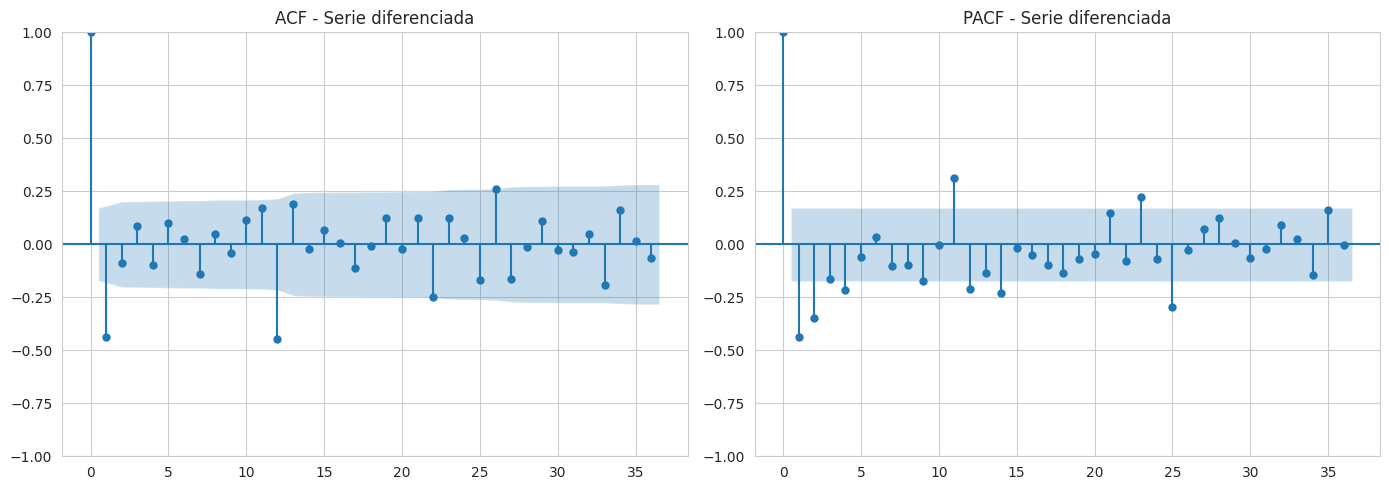

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(serie_diff_completa, lags=36, ax=axes[0])
axes[0].set_title('ACF - Serie diferenciada')

plot_pacf(serie_diff_completa, lags=36, ax=axes[1])
axes[1].set_title('PACF - Serie diferenciada')

plt.tight_layout()
plt.show()

## Bloque 7: División en conjunto de entrenamiento y prueba

Dividimos la serie en entrenamiento y prueba, respetando el orden temporal
(sin mezclar aleatoriamente). Se reservan los últimos 12 meses como conjunto
de prueba, para evaluar la capacidad de pronóstico a un horizonte de un año.

Entrenamiento: 2008-01-01 00:00:00 - 2018-12-01 00:00:00 (132 obs)
Prueba: 2019-01-01 00:00:00 - 2019-12-01 00:00:00 (12 obs)


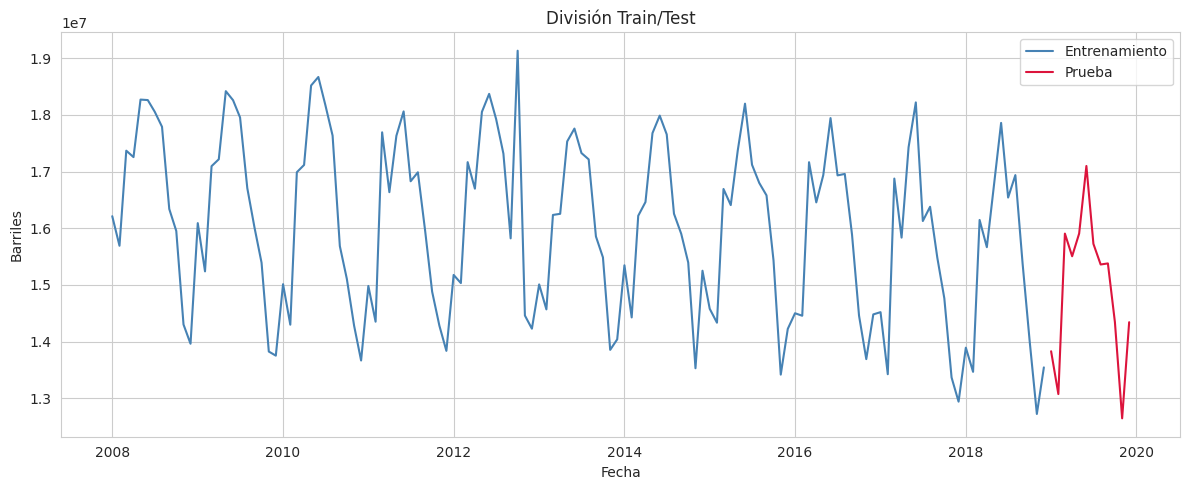

In [14]:
# Reservamos los últimos 12 meses como test
n_test = 12
train = serie_produccion.iloc[:-n_test]
test = serie_produccion.iloc[-n_test:]

print("Entrenamiento:", train.index.min(), "-", train.index.max(), f"({len(train)} obs)")
print("Prueba:", test.index.min(), "-", test.index.max(), f"({len(test)} obs)")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Entrenamiento', color='#4682B4')
plt.plot(test.index, test.values, label='Prueba', color='#DC143C')
plt.title('División Train/Test')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Bloque 8: Entrenamiento del modelo SARIMA

Entrenamos un modelo SARIMA(0,1,1)(0,1,1)_12, cuyos órdenes fueron definidos
a partir del análisis de ACF/PACF del Bloque 6 (patrón característico del
"modelo Airline" de Box-Jenkins: diferenciación regular y estacional, con un
único término de media móvil en cada nivel). El modelo se ajusta únicamente
sobre el conjunto de entrenamiento (2008-2018).

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definir y entrenar el modelo SARIMA
modelo_sarima = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit(disp=False)

# Resumen del modelo
print(resultado_sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      month_current   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1564.506
Date:                            Thu, 16 Jul 2026   AIC                           3135.012
Time:                                    16:36:33   BIC                           3142.974
Sample:                                01-01-2008   HQIC                          3138.238
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7060      0.084     -8.385      0.000      -0.871      -0.541
ma.S.L12      -0.2870      0.049   

## Bloque 8.5: Corrección de frecuencia del índice temporal

Se fija explícitamente la frecuencia mensual (`MS`) del índice para evitar
advertencias de statsmodels y garantizar la correcta generación de fechas
futuras al pronosticar.

In [17]:
train = train.asfreq('MS')
test = test.asfreq('MS')

modelo_sarima = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      month_current   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1564.506
Date:                            Thu, 16 Jul 2026   AIC                           3135.012
Time:                                    16:37:50   BIC                           3142.974
Sample:                                01-01-2008   HQIC                          3138.238
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7060      0.084     -8.385      0.000      -0.871      -0.541
ma.S.L12      -0.2870      0.049   

## Bloque 9: Diagnóstico de residuales del modelo SARIMA

Analizamos los residuales del modelo mediante los gráficos de diagnóstico
estándar de statsmodels: serie de residuales en el tiempo, histograma con
curva normal de referencia, gráfico Q-Q y correlograma (ACF). Esto permite
verificar si el modelo capturó adecuadamente la estructura de la serie o
si aún queda información sin explicar (por ejemplo, el outlier detectado
en 2012-2013).

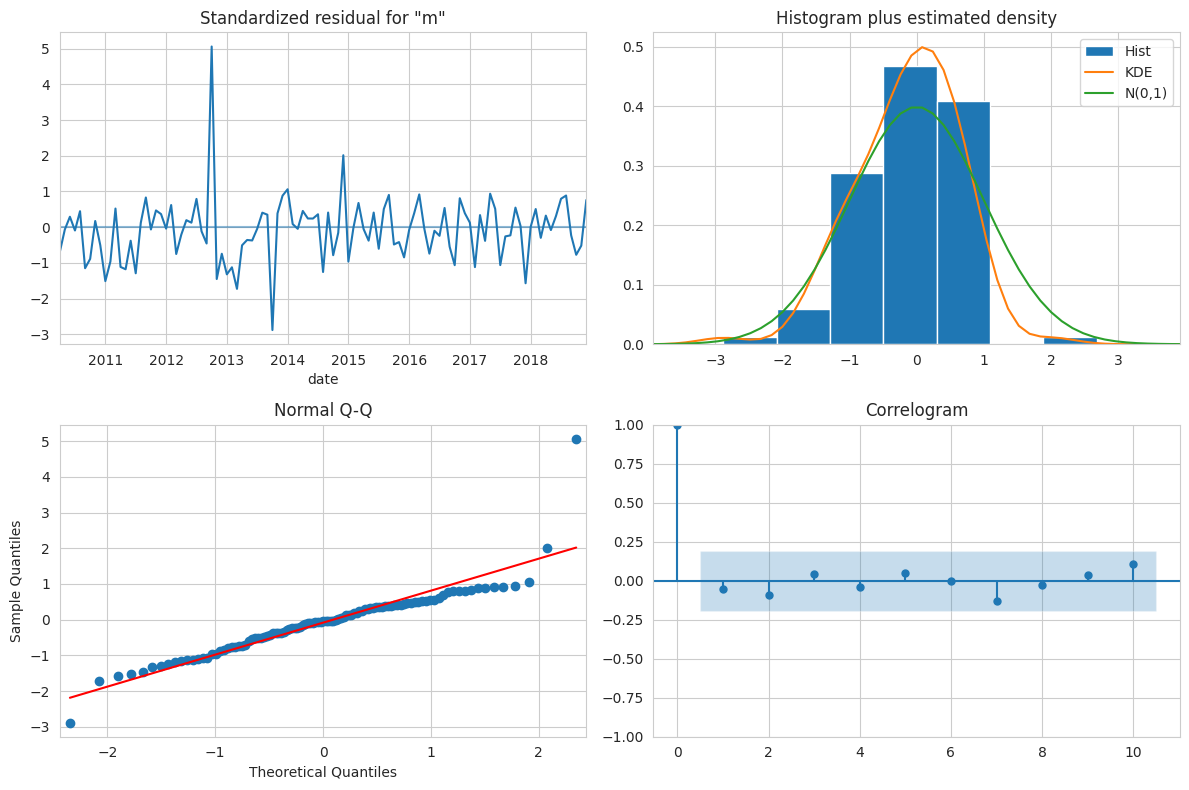

In [18]:
resultado_sarima.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Conclusión: Diagnóstico de residuales

El correlograma no muestra autocorrelación significativa, confirmando que el
modelo SARIMA(0,1,1)(0,1,1)_12 capturó correctamente la estructura de la serie.
Los residuales presentan colas más pesadas que una distribución normal, debido
a un valor atípico puntual en 2012-2013 (Jarque-Bera=411.27, Kurtosis=12.28).
Esto se documenta como limitación conocida, sin invalidar el uso del modelo
para pronosticar.

## Bloque 10: Pronóstico sobre el conjunto de prueba

Utilizamos el modelo entrenado para generar el pronóstico de los 12 meses
del conjunto de prueba (2019), junto con su intervalo de confianza del 95%.
Comparamos visualmente el pronóstico contra los valores reales.

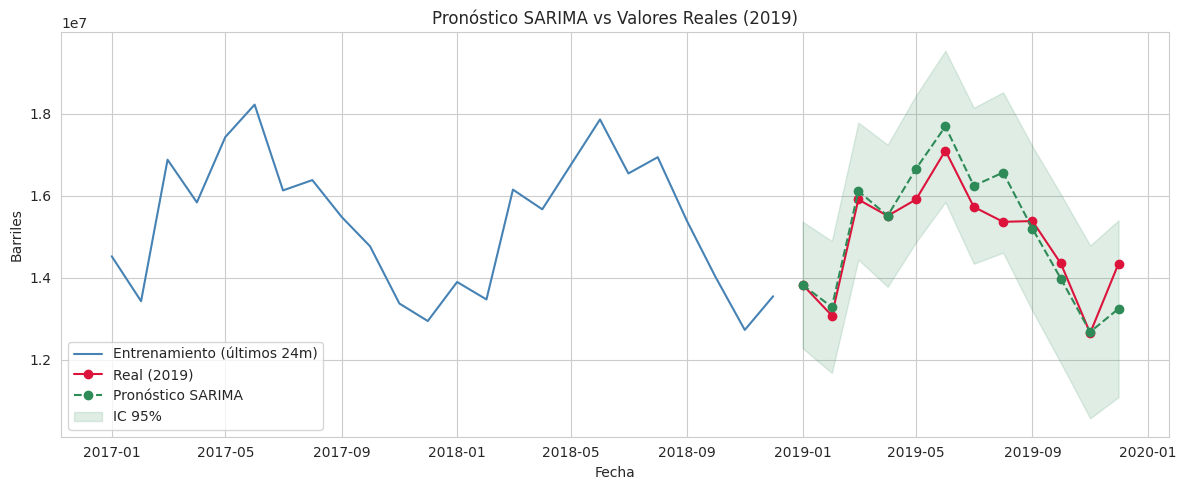

In [19]:
# Pronóstico para el horizonte de test (12 meses)
pronostico = resultado_sarima.get_forecast(steps=n_test)
pred_media = pronostico.predicted_mean
pred_ic = pronostico.conf_int(alpha=0.05)

# Gráfico comparativo
plt.figure(figsize=(12, 5))
plt.plot(train.index[-24:], train.values[-24:], label='Entrenamiento (últimos 24m)', color='#4682B4')
plt.plot(test.index, test.values, label='Real (2019)', color='#DC143C', marker='o')
plt.plot(pred_media.index, pred_media.values, label='Pronóstico SARIMA', color='#2E8B57', marker='o', linestyle='--')
plt.fill_between(pred_ic.index, pred_ic.iloc[:, 0], pred_ic.iloc[:, 1], color='#2E8B57', alpha=0.15, label='IC 95%')
plt.title('Pronóstico SARIMA vs Valores Reales (2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión: Pronóstico SARIMA vs valores reales (2019)

El modelo SARIMA logra capturar correctamente la forma estacional de la serie,
replicando los picos (mitad de año) y valles (fin de año) observados en los
valores reales de 2019. Los valores reales caen dentro del intervalo de
confianza del 95% en la gran mayoría de los meses, aunque se observa una
leve sobreestimación en abril-mayo y una subestimación en octubre. El error
puntual se cuantifica en el siguiente bloque mediante RMSE, MAE y MAPE.

## Bloque 11: Métricas de evaluación (SARIMA)

Calculamos las métricas obligatorias de evaluación (RMSE, MAE, MAPE) comparando
el pronóstico del modelo SARIMA contra los valores reales del conjunto de prueba.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_sarima = np.sqrt(mean_squared_error(test, pred_media))
mae_sarima = mean_absolute_error(test, pred_media)
mape_sarima = mean_absolute_percentage_error(test, pred_media) * 100

print(f"RMSE: {rmse_sarima:,.0f} barriles")
print(f"MAE:  {mae_sarima:,.0f} barriles")
print(f"MAPE: {mape_sarima:.2f}%")

RMSE: 583,913 barriles
MAE:  430,181 barriles
MAPE: 2.82%


## Bloque 12: Ingeniería de atributos para XGBoost

A diferencia de SARIMA, un modelo de Machine Learning como XGBoost no entiende
el concepto de "serie temporal" de forma nativa: necesita atributos (features)
explícitos como input. Construimos:
- **Variables de calendario:** mes y trimestre, para capturar la estacionalidad.
- **Variables de rezago (lags):** valores de la serie en t-1, t-2, t-3 y t-12,
  que le permiten al modelo "ver" el pasado reciente y el mismo mes del año anterior.

Es importante generar estos atributos usando únicamente información disponible
hasta el momento de la predicción, para evitar fuga de datos (data leakage).

In [21]:
# Partimos de la serie completa para generar los atributos
df_features = serie_produccion.to_frame(name='barriles')

# Variables de calendario
df_features['mes'] = df_features.index.month
df_features['trimestre'] = df_features.index.quarter

# Variables de rezago (lags) - usan solo información pasada, sin leakage
df_features['lag_1'] = df_features['barriles'].shift(1)
df_features['lag_2'] = df_features['barriles'].shift(2)
df_features['lag_3'] = df_features['barriles'].shift(3)
df_features['lag_12'] = df_features['barriles'].shift(12)

# Eliminamos las filas iniciales con NaN generadas por los lags
df_features = df_features.dropna()

print("Dimensiones finales:", df_features.shape)
df_features.head()

Dimensiones finales: (132, 7)


,barriles,mes,trimestre,lag_1,lag_2,lag_3,lag_12
date,,,,,,,
2009-01-01,16089611,1,1,13961733.0,14301054.0,15951285.0,16211480.0
2009-02-01,15238281,2,1,16089611.0,13961733.0,14301054.0,15690494.0
2009-03-01,17094274,3,1,15238281.0,16089611.0,13961733.0,17367476.0
2009-04-01,17216410,4,2,17094274.0,15238281.0,16089611.0,17254160.0
2009-05-01,18417624,5,2,17216410.0,17094274.0,15238281.0,18269043.0


## Bloque 13: División train/test y entrenamiento de XGBoost

Dividimos el dataset de atributos respetando el mismo criterio temporal
que usamos con SARIMA: los últimos 12 meses (2019) como conjunto de prueba,
y el resto como entrenamiento. Entrenamos un modelo XGBoost usando las
variables de calendario y de rezago como predictores.

In [22]:
from xgboost import XGBRegressor

# Separar predictores (X) y variable objetivo (y)
X = df_features.drop(columns='barriles')
y = df_features['barriles']

# Split train/test respetando el orden temporal (últimos 12 meses = test)
X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]

print("Entrenamiento:", X_train.index.min(), "-", X_train.index.max(), f"({len(X_train)} obs)")
print("Prueba:", X_test.index.min(), "-", X_test.index.max(), f"({len(X_test)} obs)")

# Entrenar el modelo
modelo_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
modelo_xgb.fit(X_train, y_train)

print("\nModelo entrenado ✓")

Entrenamiento: 2009-01-01 00:00:00 - 2018-12-01 00:00:00 (120 obs)
Prueba: 2019-01-01 00:00:00 - 2019-12-01 00:00:00 (12 obs)

Modelo entrenado ✓


## Bloque 14: Pronóstico de XGBoost sobre el conjunto de prueba

Generamos las predicciones del modelo XGBoost para el conjunto de prueba (2019)
y las comparamos visualmente contra los valores reales.

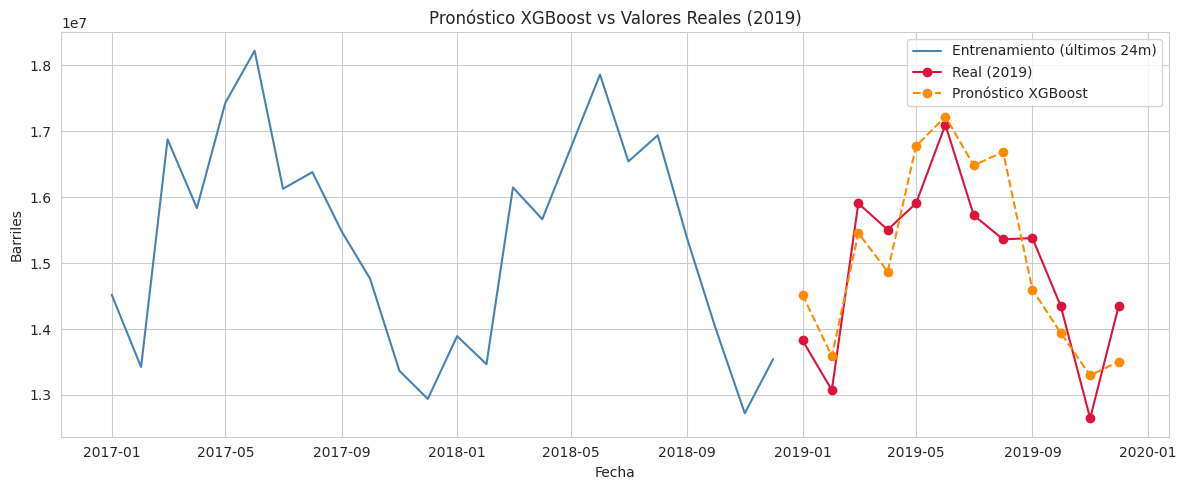

In [23]:
pred_xgb = modelo_xgb.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(train.index[-24:], train.values[-24:], label='Entrenamiento (últimos 24m)', color='#4682B4')
plt.plot(y_test.index, y_test.values, label='Real (2019)', color='#DC143C', marker='o')
plt.plot(y_test.index, pred_xgb, label='Pronóstico XGBoost', color='#FF8C00', marker='o', linestyle='--')
plt.title('Pronóstico XGBoost vs Valores Reales (2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Bloque 15: Métricas de evaluación (XGBoost)

Calculamos las mismas métricas obligatorias (RMSE, MAE, MAPE) para el modelo
XGBoost, usando el mismo conjunto de prueba (2019) que en SARIMA, para
garantizar una comparación justa entre ambos modelos.

In [24]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, pred_xgb) * 100

print(f"RMSE: {rmse_xgb:,.0f} barriles")
print(f"MAE:  {mae_xgb:,.0f} barriles")
print(f"MAPE: {mape_xgb:.2f}%")

RMSE: 727,213 barriles
MAE:  670,032 barriles
MAPE: 4.53%


## Bloque 16: Comparación final de modelos

Consolidamos las métricas de ambos modelos en una tabla y un gráfico de barras,
para visualizar de forma clara cuál tuvo mejor desempeño en el pronóstico de
producción mensual de cerveza (2019).

                 Modelo          RMSE           MAE  MAPE (%)
SARIMA(0,1,1)(0,1,1)_12 583912.765356 430181.425435  2.823870
                XGBoost 727212.892119 670032.250000  4.531318


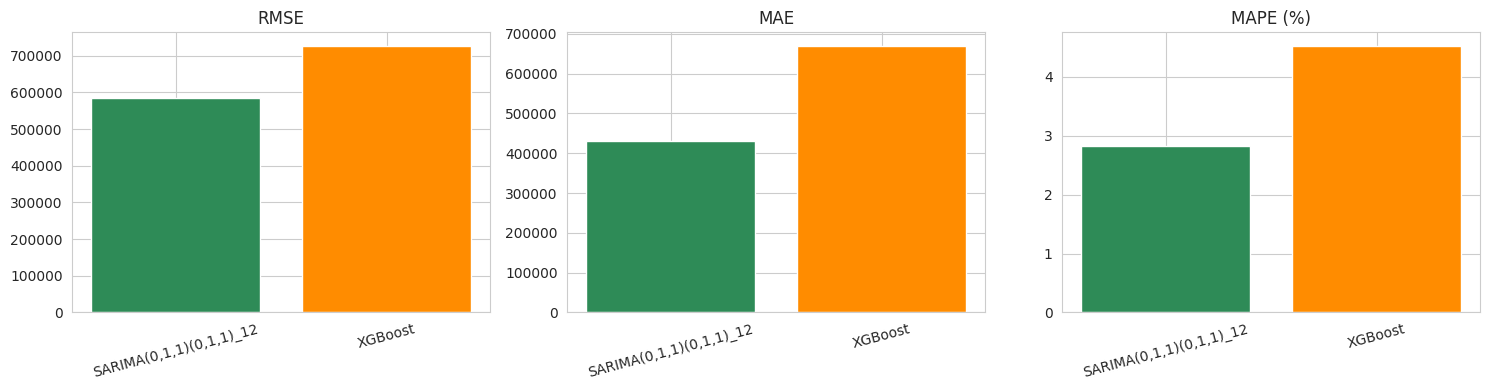

In [25]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo': ['SARIMA(0,1,1)(0,1,1)_12', 'XGBoost'],
    'RMSE': [rmse_sarima, rmse_xgb],
    'MAE': [mae_sarima, mae_xgb],
    'MAPE (%)': [mape_sarima, mape_xgb]
})
print(comparacion.to_string(index=False))

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['RMSE', 'MAE', 'MAPE (%)']
colores = ['#2E8B57', '#FF8C00']

for i, metrica in enumerate(metricas):
    axes[i].bar(comparacion['Modelo'], comparacion[metrica], color=colores)
    axes[i].set_title(metrica)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Bloque 17: Análisis de error por horizonte de pronóstico

En lugar de mirar solo el error promedio agregado, analizamos cómo evoluciona
el error absoluto |y - ŷ| mes a mes dentro del horizonte de test (h=1 a h=12).
Esto permite identificar si algún modelo pierde precisión a medida que el
horizonte de pronóstico se aleja del último dato observado, o si algún mes
en particular concentra la mayor parte del error.

    Mes  Horizonte (h)  Error SARIMA  Error XGBoost
2019-01              1  7.707594e+03       691252.0
2019-02              2  2.075558e+05       512646.0
2019-03              3  2.039456e+05       452300.0
2019-04              4  2.531496e+03       634622.0
2019-05              5  7.493587e+05       867190.0
2019-06              6  5.893177e+05       123723.0
2019-07              7  5.153687e+05       756602.0
2019-08              8  1.203007e+06      1325665.0
2019-09              9  1.836854e+05       782609.0
2019-10             10  3.702123e+05       406697.0
2019-11             11  2.791084e+04       650361.0
2019-12             12  1.101576e+06       836719.0


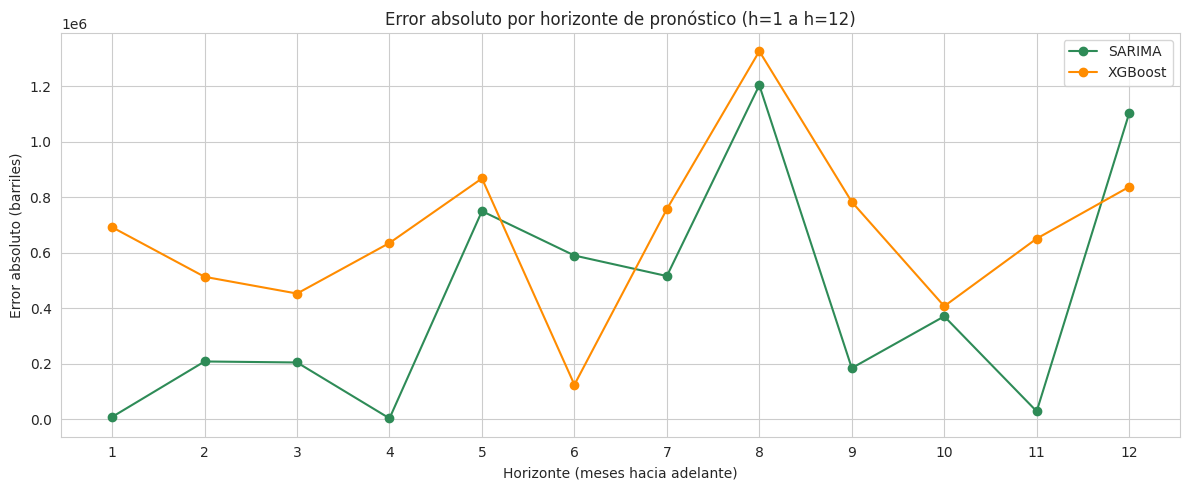

In [26]:
# Error absoluto por horizonte para cada modelo
errores_sarima = np.abs(test.values - pred_media.values)
errores_xgb = np.abs(y_test.values - pred_xgb)

df_errores = pd.DataFrame({
    'Mes': test.index.strftime('%Y-%m'),
    'Horizonte (h)': range(1, n_test + 1),
    'Error SARIMA': errores_sarima,
    'Error XGBoost': errores_xgb
})

print(df_errores.to_string(index=False))

# Gráfico del error por horizonte
plt.figure(figsize=(12, 5))
plt.plot(df_errores['Horizonte (h)'], df_errores['Error SARIMA'], marker='o', label='SARIMA', color='#2E8B57')
plt.plot(df_errores['Horizonte (h)'], df_errores['Error XGBoost'], marker='o', label='XGBoost', color='#FF8C00')
plt.title('Error absoluto por horizonte de pronóstico (h=1 a h=12)')
plt.xlabel('Horizonte (meses hacia adelante)')
plt.ylabel('Error absoluto (barriles)')
plt.xticks(range(1, n_test + 1))
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión: Error por horizonte de pronóstico

El error no crece de forma monótona con el horizonte (h), lo cual indica que
la dificultad de pronóstico no depende principalmente de la distancia al
último dato observado. En cambio, se observa un pico de error compartido por
ambos modelos en h=8 (agosto 2019), sugiriendo un mes particularmente atípico
o difícil de anticipar para ambas metodologías. SARIMA muestra menor error
que XGBoost en 8 de los 12 meses evaluados, consistente con su mejor
desempeño agregado (MAPE 2.82% vs 4.53%).

## Bloque 18: Cuestión 1 — Ventana de entrenamiento óptima

Evaluamos si usar **todo el histórico disponible** para entrenar produce mejores
resultados que usar una **ventana deslizante** (solo los últimos N meses),
probando distintos tamaños de ventana y comparando el MAPE resultante sobre
el mismo conjunto de prueba (2019).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Ventana (meses)  MAPE (%)
             24  5.066559
             36  7.129093
             48  3.586761
             60  3.609179
             72  2.999489
             96  2.852427
Todos los datos  2.823870


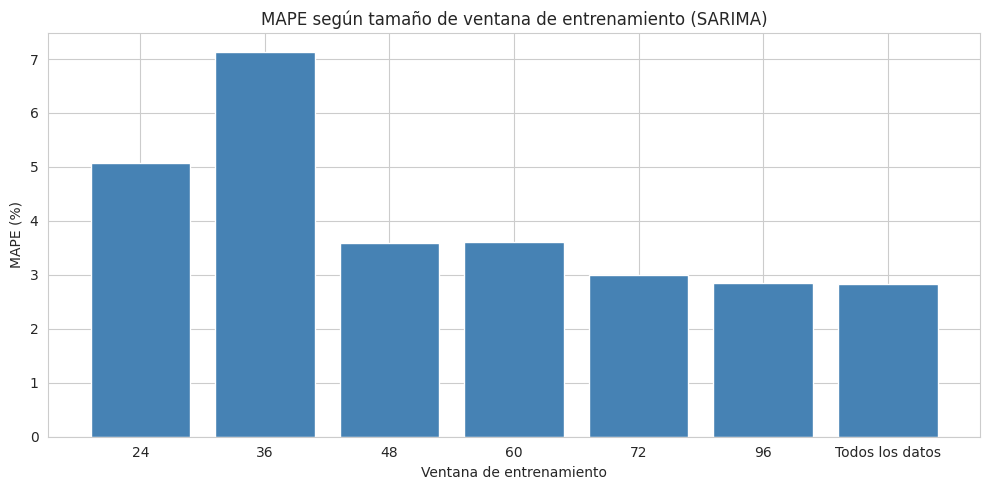

In [27]:
ventanas = [24, 36, 48, 60, 72, 96, len(train)]  # len(train)=132 equivale a "todos los datos"
resultados_ventana = []

for v in ventanas:
    train_v = train.iloc[-v:] if v < len(train) else train

    modelo_v = SARIMAX(
        train_v,
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resultado_v = modelo_v.fit(disp=False)
    pred_v = resultado_v.get_forecast(steps=n_test).predicted_mean

    mape_v = mean_absolute_percentage_error(test, pred_v) * 100
    resultados_ventana.append({'Ventana (meses)': v if v < len(train) else 'Todos los datos', 'MAPE (%)': mape_v})

df_ventanas = pd.DataFrame(resultados_ventana)
print(df_ventanas.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(df_ventanas['Ventana (meses)'].astype(str), df_ventanas['MAPE (%)'], color='#4682B4')
plt.title('MAPE según tamaño de ventana de entrenamiento (SARIMA)')
plt.xlabel('Ventana de entrenamiento')
plt.ylabel('MAPE (%)')
plt.tight_layout()
plt.show()

## Conclusión — Cuestión 1: Ventana de entrenamiento óptima

El MAPE disminuye a medida que aumenta el tamaño de la ventana de
entrenamiento, alcanzando su mínimo (2.82%) al usar **todo el histórico
disponible** (132 meses). Esto indica que, para esta serie, el modelo se
beneficia de contar con más ciclos estacionales completos para estimar
correctamente los parámetros, en lugar de limitarse a datos recientes.
Se observa una excepción en la ventana de 36 meses (MAPE=7.12%), superior
incluso a la ventana más corta de 24 meses, lo cual sugiere que ese recorte
específico captura un tramo particularmente inestable de la serie más que
un patrón general de las ventanas cortas.

**Conclusión práctica:** para este caso, no conviene usar ventana deslizante;
es preferible entrenar con todos los datos disponibles.

## Bloque 19: Cuestión 2 — Intervalo óptimo del pasado como input

Evaluamos distintas configuraciones de variables de rezago (lags) para el
modelo XGBoost, probando cuántos meses hacia atrás conviene incluir como
input, y comparando el MAPE resultante sobre el mismo conjunto de prueba.

Configuración  MAPE (%)
   Solo lag_1  6.073162
     Lags 1-3  4.002215
     Lags 1-6  5.678868
Lags 1-3 y 12  4.531318
    Lags 1-12  5.009285


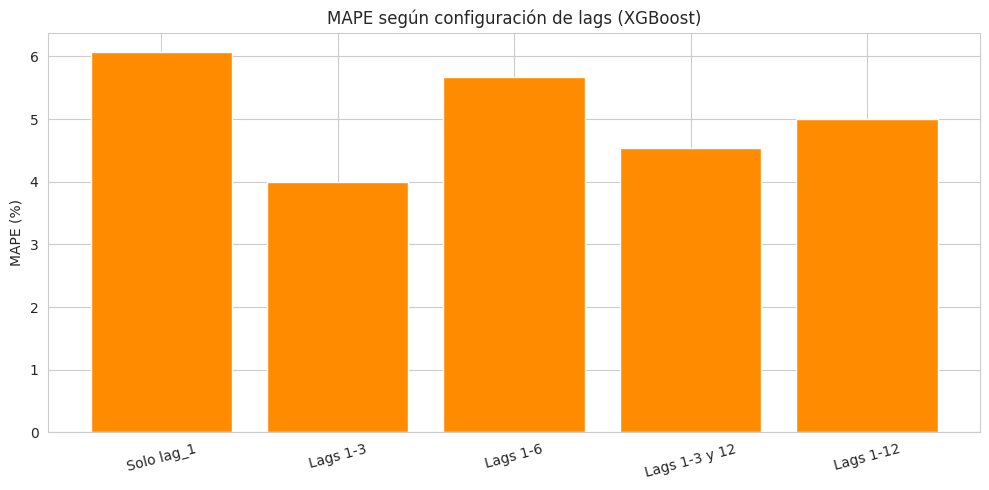

In [28]:
configuraciones_lags = {
    'Solo lag_1': [1],
    'Lags 1-3': [1, 2, 3],
    'Lags 1-6': [1, 2, 3, 4, 5, 6],
    'Lags 1-3 y 12': [1, 2, 3, 12],
    'Lags 1-12': list(range(1, 13)),
}

resultados_lags = []

for nombre, lags in configuraciones_lags.items():
    df_temp = serie_produccion.to_frame(name='barriles')
    df_temp['mes'] = df_temp.index.month
    df_temp['trimestre'] = df_temp.index.quarter
    for lag in lags:
        df_temp[f'lag_{lag}'] = df_temp['barriles'].shift(lag)
    df_temp = df_temp.dropna()

    X_temp = df_temp.drop(columns='barriles')
    y_temp = df_temp['barriles']
    X_tr, X_te = X_temp.iloc[:-n_test], X_temp.iloc[-n_test:]
    y_tr, y_te = y_temp.iloc[:-n_test], y_temp.iloc[-n_test:]

    modelo_temp = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    modelo_temp.fit(X_tr, y_tr)
    pred_temp = modelo_temp.predict(X_te)

    mape_temp = mean_absolute_percentage_error(y_te, pred_temp) * 100
    resultados_lags.append({'Configuración': nombre, 'MAPE (%)': mape_temp})

df_lags = pd.DataFrame(resultados_lags)
print(df_lags.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(df_lags['Configuración'], df_lags['MAPE (%)'], color='#FF8C00')
plt.title('MAPE según configuración de lags (XGBoost)')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Conclusión — Cuestión 2: Intervalo óptimo del pasado como input

La configuración con **lags 1 a 3** obtuvo el menor MAPE (≈4.0%) entre todas
las probadas, superando incluso a configuraciones que incluyen el lag_12
(que buscaba capturar explícitamente la estacionalidad anual). Esto sugiere
que, para XGBoost, las variables de calendario (mes, trimestre) ya aportan
suficiente información estacional, y agregar lags más lejanos (6 o 12 meses)
introduce ruido o redundancia en lugar de ayuda. Usar únicamente el pasado
más reciente (últimos 3 meses) resulta ser el intervalo óptimo como input
para este modelo.

**Conclusión práctica:** un intervalo corto del pasado (3 meses) es
suficiente y preferible sobre incluir el ciclo estacional completo como lag,
dado que esa información ya es capturada por las variables de calendario.

## Bloque 20: Modelo XGBoost final con configuración óptima

A partir del resultado de la Cuestión 2, actualizamos el modelo XGBoost
"oficial" del proyecto para usar únicamente los lags 1, 2 y 3 (mejor
configuración encontrada), en lugar de la configuración inicial con lag_12.
Recalculamos sus métricas y actualizamos la tabla comparativa final frente
a SARIMA.

RMSE: 694,718 barriles
MAE:  585,714 barriles
MAPE: 4.00%

                     Modelo          RMSE           MAE  MAPE (%)
   SARIMA(0,1,1)(0,1,1)_12 583912.765356 430181.425435  2.823870
XGBoost (lags 1-3, óptimo) 694718.181112 585714.500000  4.002215


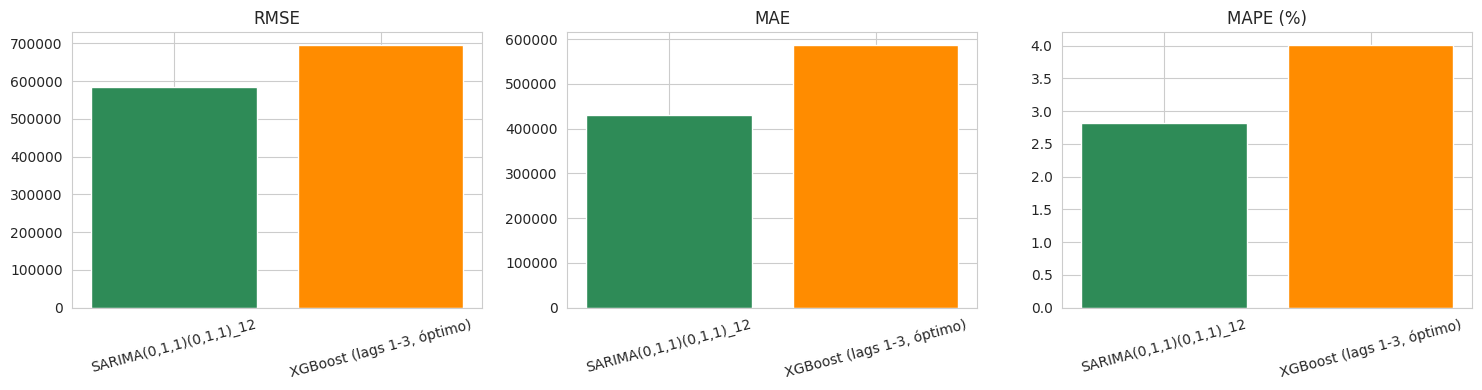

In [29]:
# Reconstruir atributos con la configuración óptima (lags 1-3, sin lag_12)
df_features_final = serie_produccion.to_frame(name='barriles')
df_features_final['mes'] = df_features_final.index.month
df_features_final['trimestre'] = df_features_final.index.quarter
df_features_final['lag_1'] = df_features_final['barriles'].shift(1)
df_features_final['lag_2'] = df_features_final['barriles'].shift(2)
df_features_final['lag_3'] = df_features_final['barriles'].shift(3)
df_features_final = df_features_final.dropna()

X_final = df_features_final.drop(columns='barriles')
y_final = df_features_final['barriles']

X_train_final, X_test_final = X_final.iloc[:-n_test], X_final.iloc[-n_test:]
y_train_final, y_test_final = y_final.iloc[:-n_test], y_final.iloc[-n_test:]

# Entrenar el modelo final
modelo_xgb_final = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
modelo_xgb_final.fit(X_train_final, y_train_final)
pred_xgb_final = modelo_xgb_final.predict(X_test_final)

# Recalcular métricas
rmse_xgb_final = np.sqrt(mean_squared_error(y_test_final, pred_xgb_final))
mae_xgb_final = mean_absolute_error(y_test_final, pred_xgb_final)
mape_xgb_final = mean_absolute_percentage_error(y_test_final, pred_xgb_final) * 100

print(f"RMSE: {rmse_xgb_final:,.0f} barriles")
print(f"MAE:  {mae_xgb_final:,.0f} barriles")
print(f"MAPE: {mape_xgb_final:.2f}%")

# Actualizar la tabla comparativa final
comparacion_final = pd.DataFrame({
    'Modelo': ['SARIMA(0,1,1)(0,1,1)_12', 'XGBoost (lags 1-3, óptimo)'],
    'RMSE': [rmse_sarima, rmse_xgb_final],
    'MAE': [mae_sarima, mae_xgb_final],
    'MAPE (%)': [mape_sarima, mape_xgb_final]
})
print("\n", comparacion_final.to_string(index=False))

# Gráfico comparativo actualizado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['RMSE', 'MAE', 'MAPE (%)']
colores = ['#2E8B57', '#FF8C00']

for i, metrica in enumerate(metricas):
    axes[i].bar(comparacion_final['Modelo'], comparacion_final[metrica], color=colores)
    axes[i].set_title(metrica)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Bloque 21: Conclusiones finales

**Resumen de resultados**

| Modelo | RMSE | MAE | MAPE |
|---|---|---|---|
| SARIMA(0,1,1)(0,1,1)_12 | 583,913 | 430,181 | 2.82% |
| XGBoost (lags 1-3, óptimo) | 694,718 | 585,715 | 4.00% |

**Hallazgos principales**

1. **SARIMA superó a XGBoost** en las tres métricas de evaluación, incluso
   luego de optimizar la configuración de atributos del modelo de ML. Esto
   confirma que, para series con estacionalidad fuerte, tendencia suave y
   un volumen de datos moderado (132 observaciones), un modelo estadístico
   clásico puede seguir siendo superior a uno de Machine Learning más
   complejo — no siempre "más sofisticado" implica "más preciso".

2. **Cuestión 1 (ventana de entrenamiento):** usar **todo el histórico
   disponible** produjo el mejor resultado (MAPE=2.82%), superando a
   cualquier ventana deslizante probada (24 a 96 meses).

3. **Cuestión 2 (intervalo del pasado como input):** para XGBoost, un
   intervalo corto de **lags 1 a 3** resultó óptimo, superando incluso a
   configuraciones que incluían el lag estacional (lag_12), dado que las
   variables de calendario ya capturaban esa información.

4. **Limitaciones detectadas:** se identificó un valor atípico puntual en
   2012-2013, y se documentó (aunque no se utilizó en el modelado final)
   un quiebre estructural no explicado en la serie de insumos
   (`brewing_materials.csv`) a partir de 2016, que motivó el cambio hacia
   la serie de producción total de barriles (`beer_taxed.csv`).

**Aplicación práctica:** el modelo SARIMA entrenado con todo el histórico
disponible ofrece un pronóstico confiable (error promedio ~2.8%) para
anticipar la producción mensual de cerveza en EE.UU., útil para la
planificación de insumos, logística y capacidad productiva de la industria.

## Bloque 22: Exportar métricas y gráficos para el repositorio

Guardamos la tabla comparativa de métricas en un archivo CSV, y el gráfico
comparativo final en una imagen PNG, para incluirlos en la carpeta `results/`
del repositorio de GitHub.

metricas.csv guardado ✓


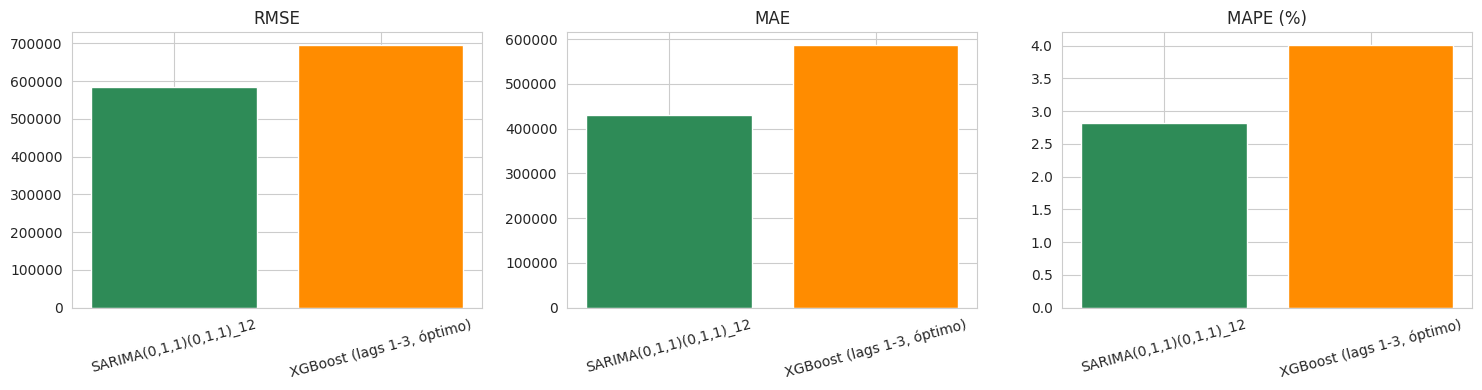

graficos.png guardado ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# 1. Guardar la tabla de métricas
comparacion_final.to_csv('metricas.csv', index=False)
print("metricas.csv guardado ✓")

# 2. Guardar el gráfico comparativo final como imagen
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['RMSE', 'MAE', 'MAPE (%)']
colores = ['#2E8B57', '#FF8C00']

for i, metrica in enumerate(metricas):
    axes[i].bar(comparacion_final['Modelo'], comparacion_final[metrica], color=colores)
    axes[i].set_title(metrica)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('graficos.png', dpi=150, bbox_inches='tight')
plt.show()
print("graficos.png guardado ✓")

# 3. Descargar ambos archivos a tu computadora
from google.colab import files
files.download('metricas.csv')
files.download('graficos.png')